In [7]:
import sys 
sys.path.append("/home/feity/cryoem/")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import utils
import torch
import importlib 
import modules
import data

import postprocess 

import pickle
importlib.reload(data)
importlib.reload(modules)
importlib.reload(postprocess)

/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'postprocess' from '/home/feity/cryoem/postprocess.py'>

### hsp60

In [10]:
df2 = pd.read_csv("/home/feity/compare/deepict/DeePiCt/3d_cnn/metadata_dxd20240920_hsp60.csv")
tomo_paths = dict(df2["tomo"])
for name in tomo_paths:
    # if path in cache:
    #     vol = cache[path]
    # else:
    # if name.endswith(".mrc"):
    vol = utils.readTomogram(tomo_paths[name])
    # Normalize each 2D slice
    # if self.norm == "zscore":
    #     vol = np.stack(
    #         [(sl - sl.mean()) / (sl.std() + 1e-6) for sl in vol], axis=0
    #     )
    # elif self.norm == "hist":
    from skimage import exposure
    vol = np.stack([exposure.equalize_hist(sl) for sl in vol], axis=0)
    # else:
    #     vol = np.load(tomo_paths[name])
    np.save(f"/data/transformer_project/transforemer_model/train_data/training/newdata/norm_%s.npy" % name, vol)
    df2.loc[name, "norm"] = f"/data/transformer_project/transforemer_model/train_data/training/newdata/norm_%s.npy" % name 
df2.to_csv("/home/feity/compare/deepict/DeePiCt/3d_cnn/metadata_dxd20240920_hsp60_norm.csv", index=False)

In [28]:
with open("/home/feity/cryoem/temp/hsp60_centers.pkl", "rb") as f:
    hsp60_centers = pickle.load(f)
names = ["24092001", "24092002", "24092018", "24092024", "24092028", "24092031"]
df_tomo = pd.read_csv("/home/feity/compare/deepict/DeePiCt/3d_cnn/metadata_dxd20240920_hsp60_norm.csv")
df_tomo["tomo_name"] = df_tomo["tomo_name"].astype(str)
df_tomo = df_tomo.set_index("tomo_name")

dfs = []
df_predicts = []
for i in names:
    print(i)
    df = pd.read_csv(f"/home/feity/cryoem/temp/hsp60/{i}/df.csv")
    # df2 = pd.read_csv(f"/home/feity/cryoem/temp/hsp60/{i}/labels.csv")
    # df2 = df2.set_index("sample")
    # mapping = dict(df2["label"]) 
    # df["if_pos"] = df["label_id"].apply(lambda x: mapping.get(x, "negative"))
    # df = df[df["if_pos"]!="negative"]
    score, predict_center, ids = postprocess.getPredictionCenters(df, "hsp60", image_size=1024, top_n=10)
    idx = np.argsort(-score)
    # idx = idx[:500]
    score = score[idx]
    predict_center = predict_center[idx]
    ids = ids[idx]
    labels = hsp60_centers[i]
    matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, labels)
    t = postprocess.calculate_metrics(matches, match_dists, score, threshold=20)
    # roc, cnt, cnt/len(centers), cnt/len(idx), len(score), len(centers)
    print(t)
    print("final score:", t["aupr2"]*t["cnts"]/len(labels))
    
    matches = np.array(matches)
    matched = matches[match_dists < 20] 
    matched = matched[:, 1]
    need = [] 
    for j in range(predict_center.shape[0]):
        if j not in matched:
            need.append(j) 
    k = [1] * len(labels) + [0] * len(need)
    
    values = np.concatenate([labels, predict_center[need]], axis=0)
    df = pd.DataFrame(values, columns=["z", "y", "x"])
    df["label"] = k
    df["tomogram"] = i
    dfs.append(df)
    print("finish", i, values.shape) 
    print(values.shape, predict_center.shape, labels.shape, t["cnts"], predict_center.shape[0] + labels.shape[0] - values.shape[0])
    
    df = pd.DataFrame(predict_center, columns=["z", "y", "x"]) 
    df["score"] = score
    df["tomogram"] = i 
    df["label"] = -1
    df_predicts.append(df)
    
    # df.head()
df_predict = pd.concat(df_predicts, ignore_index=True)
df = pd.concat(dfs, ignore_index=True)
df.head()

24092001
{'auroc': 0.8227491445901274, 'aupr': 0.5583379881386725, 'aupr2': 0.5613578386038058, 'cnts': 263}
final score: 0.4747174004913214
finish 24092001 (1230, 3)
(1230, 3) (1182, 3) (311, 3) 263 263
24092002
{'auroc': 0.789974608177918, 'aupr': 0.3591982740029583, 'aupr2': 0.36346826938685295, 'cnts': 135}
final score: 0.2955916648628021
finish 24092002 (1012, 3)
(1012, 3) (981, 3) (166, 3) 135 135
24092018
{'auroc': 0.5999458954306232, 'aupr': 0.20602568089975523, 'aupr2': 0.21292314915736385, 'cnts': 81}
final score: 0.11055625052401584
finish 24092018 (658, 3)
(658, 3) (583, 3) (156, 3) 81 81
24092024
{'auroc': 0.8006762614877753, 'aupr': 0.29833212087480354, 'aupr2': 0.3030704421773758, 'cnts': 146}
final score: 0.24999030823670546
finish 24092024 (1441, 3)
(1441, 3) (1410, 3) (177, 3) 146 146
24092028
{'auroc': 0.814528653517627, 'aupr': 0.27393437702607515, 'aupr2': 0.28825135694104, 'cnts': 47}
final score: 0.24192524600408713
finish 24092028 (604, 3)
(604, 3) (595, 3) (56,

,z,y,x,label,tomogram
0,257.954376,728.029863,550.045209,1,24092001
1,347.992593,514.000412,810.956790,1,24092001
2,138.039501,198.025780,176.952599,1,24092001
3,203.987987,105.014499,399.010771,1,24092001
4,320.960248,847.987164,628.003727,1,24092001


In [32]:
from torch.utils.data import DataLoader
import pytorch_lightning as pl
for i in names:
    train_df = df[df["tomogram"] != i]
    val_df = df[df["tomogram"] == i]
    train_tomo = df_tomo[df_tomo["tomo"].str.contains(i)==False]
    val_tomo = df_tomo[df_tomo["tomo"].str.contains(i)]
    train_dataset = data.Particle3DDataset(train_df, dict(train_tomo["norm"]), crop_size=65, norm="hist", r=10)
    val_dataset = data.Particle3DDataset(val_df, dict(val_tomo["norm"]), crop_size=65, norm="hist", r=10)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

    test_dataset = data.Particle3DDataset(df_predict[df_predict["tomogram"]==i], dict(val_tomo["norm"]), crop_size=65, norm="hist", r=0)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)
    print(i, len(train_dataset), len(val_dataset))
    model = modules.ParticleID3DNet_Binary()
    trainer = pl.Trainer(max_epochs=30, accelerator="gpu", devices=[1])
    trainer.fit(model, train_loader, val_loader) 
    model.eval() 
    preds = []
    with torch.no_grad():
        model = model.cuda()
        for batch in test_loader:
            x, y = batch
            y_hat = model(x.cuda())
            preds.append(y_hat.cpu().numpy()) 
    preds = np.concatenate(preds, axis=0)
    df_predict.loc[df_predict["tomogram"]==i, "predict_score"] = preds
    torch.save(model.state_dict(), f"/data/transformer_project/transforemer_model/train_data/training/results/step3res/hsp60/hsp60_3d_model_{i}.pth")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

   | Name      | Type              | Params | Mode 
---------------------------------------------------------
0  | conv1     | Conv3d            | 2.0 K  | train
1  | bn1       | BatchNorm3d       | 32     | train
2  | conv1_1   | Conv3d            | 32.0 K | train
3  | conv2     | Conv3d            | 64.0 K | train
4  | bn2       | BatchNorm3d       | 64     | train
5  | conv2_1   | Conv3d            | 128 K  | train
6  | conv3     | Conv3d            | 256 K  | train
7  | bn3       | BatchNorm3d       | 128    | train
8  | conv3_1   | Conv3d            | 512 K  | train
9  | pool      | MaxPool3d         | 0      | train
10 | fc1       | Linear            | 4.2 M  | train
11 | fc2       | Linear            | 129    | train
12 | criterion | BCEWithLogitsLoss | 0      | train
-------------------------------------------------

24092001 4819 1230
Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 35.70it/s]val_aupr 1.0 val_auroc nan


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch 29: 100%|██████████| 151/151 [00:24<00:00,  6.15it/s, v_num=32]

`Trainer.fit` stopped: `max_epochs=30` reached.


...

24092031 4945 1104
Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 34.79it/s]val_aupr 1.0 val_auroc nan


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch 29: 100%|██████████| 155/155 [00:24<00:00,  6.21it/s, v_num=37]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 155/155 [00:25<00:00,  6.15it/s, v_num=37]


In [ ]:
# df_predict.to_csv("/home/feity/cryoem/temp/hsp60_final_results_1019.csv")

In [32]:
import pandas as pd
df_predict = pd.read_csv("/home/feity/cryoem/temp/hsp60_final_results_1019.csv", index_col=0)
df_predict["tomogram"] = df_predict["tomogram"].astype(str)
df_predict.head()

,z,y,x,score,tomogram,label,predict_score
0,178.5,199.130079,312.642185,9.466115,24092001,-1,-2.926320
1,202.5,105.626819,399.520618,9.445540,24092001,-1,0.825199
2,186.5,107.411128,407.439210,9.426011,24092001,-1,0.497018
3,155.1,62.179599,397.171260,9.424313,24092001,-1,-0.919820
4,204.5,222.821178,496.093943,9.412305,24092001,-1,1.017800


In [36]:
import pickle
import numpy as np
import postprocess
with open("/home/feity/cryoem/temp/hsp60_centers.pkl", "rb") as f:
    hsp60_centers = pickle.load(f)
names = ["24092001", "24092002", "24092018", "24092024", "24092028", "24092031"]
dfs = []
for i in names:
    print(i)
    df = df_predict[df_predict["tomogram"] == i]
    # df = pd.read_csv(f"/home/feity/cryoem/temp/hsp60/{i}/df.csv")
    # df2 = pd.read_csv(f"/home/feity/cryoem/temp/hsp60/{i}/labels.csv")
    # df2 = df2.set_index("sample")
    # mapping = dict(df2["label"]) 
    # df["if_pos"] = df["label_id"].apply(lambda x: mapping.get(x, "negative"))
    # df = df[df["if_pos"]!="negative"]
    # score, predict_center, ids = postprocess.getPredictionCenters(df, "hsp60", image_size=1024, top_n=10)
    score = df["predict_score"].values 
    predict_center = df[["z", "y", "x"]].values
    ids = df.index.values
    idx = np.argsort(-score)
    # idx = idx[:500]
    score = score[idx]
    predict_center = predict_center[idx]
    ids = ids[idx]
    labels = hsp60_centers[i]
    matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, labels)
    t = postprocess.calculate_metrics(matches, match_dists, score, threshold=15)
    df["matched"] = False
    matches = np.array(matches)
    df.loc[ids[matches[match_dists < 15][:,1]], "matched"] = True
    dfs.append(df)
    # roc, cnt, cnt/len(centers), cnt/len(idx), len(score), len(centers)
    print(t)
    print("final score:", t["aupr2"]*t["cnts"]/len(labels))

24092001
{'auroc': 0.9171404446946243, 'aupr': 0.7701385839249328, 'aupr2': 0.770885580666842, 'cnts': 247}
final score: 0.6122467473463343
24092002
{'auroc': 0.8943677053217689, 'aupr': 0.5653915380333224, 'aupr2': 0.5678550662365942, 'cnts': 132}
final score: 0.4515474020676532
24092018
{'auroc': 0.9246001523229246, 'aupr': 0.6717262784855096, 'aupr2': 0.6744228088728671, 'cnts': 78}
final score: 0.33721140443643355
24092024
{'auroc': 0.9128483208712338, 'aupr': 0.5978400170221561, 'aupr2': 0.6028457684032824, 'cnts': 139}
final score: 0.47342125315286016
24092028
{'auroc': 0.9308558558558558, 'aupr': 0.48512309284927146, 'aupr2': 0.495154525761845, 'cnts': 40}
final score: 0.3536818041156035
24092031
{'auroc': 0.9448038378368556, 'aupr': 0.6790173119106199, 'aupr2': 0.6825657693915954, 'cnts': 113}
final score: 0.5431685347975371


/tmp/ipykernel_2458337/1271157404.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["matched"] = False
/tmp/ipykernel_2458337/1271157404.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["matched"] = False
/tmp/ipykernel_2458337/1271157404.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

In [37]:
df = pd.concat(dfs, ignore_index=True)
df.to_csv("/home/feity/cryoem/temp/hsp60_final_results_1019_with_matches.csv")
df.head()

,z,y,x,score,tomogram,label,predict_score,matched
0,178.5,199.130079,312.642185,9.466115,24092001,-1,-2.926320,False
1,202.5,105.626819,399.520618,9.445540,24092001,-1,0.825199,True
2,186.5,107.411128,407.439210,9.426011,24092001,-1,0.497018,True
3,155.1,62.179599,397.171260,9.424313,24092001,-1,-0.919820,True
4,204.5,222.821178,496.093943,9.412305,24092001,-1,1.017800,True


In [15]:
matches

[(0, 24),
 (1, 26),
 (2, 135),
 (3, 42),
 (4, 29),
 (5, 46),
 (6, 56),
 (7, 58),
 (8, 52),
 (9, 1),
 (10, 97),
 (11, 149),
 (12, 186),
 (13, 69),
 (14, 36),
 (15, 98),
 (16, 122),
 (17, 219),
 (18, 111),
 (19, 105),
 (20, 153),
 (21, 126),
 (22, 19),
 (23, 91),
 (24, 132),
 (25, 63),
 (26, 13),
 (27, 68),
 (28, 585),
 (29, 200),
 (30, 34),
 (31, 28),
 (32, 71),
 (33, 12),
 (34, 48),
 (35, 41),
 (36, 1061),
 (37, 2),
 (38, 731),
 (39, 148),
 (40, 141),
 (41, 371),
 (42, 35),
 (43, 9),
 (44, 717),
 (45, 27),
 (46, 208),
 (47, 74),
 (48, 7),
 (49, 217),
 (50, 253),
 (51, 350),
 (52, 221),
 (53, 85),
 (54, 40),
 (55, 114),
 (56, 232),
 (57, 307),
 (58, 172),
 (59, 64),
 (60, 130),
 (61, 100),
 (62, 106),
 (63, 23),
 (64, 6),
 (65, 175),
 (66, 177),
 (67, 5),
 (68, 25),
 (69, 93),
 (70, 1021),
 (71, 123),
 (72, 113),
 (73, 239),
 (74, 314),
 (75, 129),
 (76, 16),
 (77, 55),
 (78, 75),
 (79, 115),
 (80, 31),
 (81, 18),
 (82, 305),
 (83, 209),
 (84, 779),
 (85, 50),
 (86, 61),
 (87, 270),
 (8

## ribosome

In [72]:
ribo_centers = {}
all_mrc = {
    
"24092002":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092002_ribo.pkl",
"24092013":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092013_ribo.pkl",
"24092016":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092016_ribo.pkl",
"24092020":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092020_ribo.pkl",
"24092024":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092024_ribo.pkl",
"24092026":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092026_ribo.pkl",
"24092030":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092030_ribo.pkl",
"24092009":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092009_ribo.pkl",
"24092014":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092014_ribo.pkl",
"24092017":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092017_ribo.pkl",
"24092023":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092023_ribo.pkl",
"24092025":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092025_ribo.pkl",
"24092029":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092029_ribo.pkl",
"24092031":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092031_ribo.pkl"
}
dfs = [] 
cnt = 0
for name in all_mrc:
    print(name, cnt)
    cnt += 1
    # fist continue
    # continue
    with open(f"/home/feity/cryoem/temp/results/ribo_%s_gap1.pkl" % name, "rb") as f:
        res = pickle.load(f) 
    with open("/home/feity/cryoem/temp/ribo_centers_new.pkl", "rb") as f:
        ribo_centers = pickle.load(f)
    # second continue
    # continue
    centers = ribo_centers[name]
    df = res["df"]
    # subdf = postprocess.processClass(df, "ribo", **params["ribo"], use_myscan=False)
    # postprocess.markFilter(df, "ribo", subdf, **mark_and_filter["ribo"])
    
    score, predict_center, ids = postprocess.getPredictionCenters(df, "ribo", image_size=1024)
    
    idx = np.argsort(-score)
    score = score[idx]
    predict_center = predict_center[idx] 
    # predict_center = np.array(list(res["centers"].values()))
    # predict_center *= np.array((1, 1024/800, 1024/800))
    # predict_center = predict_center[:, [0, 2, 1]]
    matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, centers)
    t = postprocess.calculate_metrics(matches, match_dists, score, threshold=20)
    
    print(name, t)
    print("final score:", t["aupr2"]*t["cnts"]/len(centers))

    # values = np.concatenate([centers, predict_center[need]], axis=0)
    df = pd.DataFrame(predict_center, columns=["z", "y", "x"])
    # df["label"] = k
    df["score"] = score
    df["tomogram"] = name
    print("finish", name, cnt) 
    print(predict_center.shape, centers.shape, t["cnts"], predict_center.shape[0] + centers.shape[0] - df.shape[0])
    dfs.append(df)
df_predict = pd.concat(dfs, axis=0, ignore_index=True)
df_predict["label"] = -1

24092002 0
24092002 {'auroc': 0.7993897135360968, 'aupr': 0.8204197771069923, 'aupr2': 0.820967675247511, 'cnts': 291}
final score: 0.6157257564356333
finish 24092002 1
(532, 3) (388, 3) 291 388
24092013 1
24092013 {'auroc': 0.6308960249258757, 'aupr': 0.6946166750765261, 'aupr2': 0.6951240380070394, 'cnts': 737}
final score: 0.3525852828707419
finish 24092013 2
(1277, 3) (1453, 3) 737 1453
24092016 2
24092016 {'auroc': 0.6996300525891521, 'aupr': 0.7753945013634794, 'aupr2': 0.7760429310099947, 'cnts': 872}
final score: 0.52134779340579
finish 24092016 3
(1350, 3) (1298, 3) 872 1298
24092020 3
24092020 {'auroc': 0.7296864349011588, 'aupr': 0.8832054083770218, 'aupr2': 0.8841641873500601, 'cnts': 326}
final score: 0.6017484865889762
finish 24092020 4
(416, 3) (479, 3) 326 479
24092024 4
24092024 {'auroc': 0.7970202258413561, 'aupr': 0.8748967314724911, 'aupr2': 0.8754939132108404, 'cnts': 271}
final score: 0.6817783059774073
finish 24092024 5
(404, 3) (348, 3) 271 348
24092026 5
240920

In [99]:
df = pd.read_csv("/home/feity/cryoem/temp/ribo_all_labeled_gap1.csv")   
df["tomogram"] = df["tomogram"].astype(str)
df2 = pd.read_csv("/home/feity/compare/deepict/DeePiCt/3d_cnn/metadata_dxd20240920_ribo_norm.csv")
# print(df2)
df2["tomo_name"] = df2["tomo_name"].astype(str)
df2 = df2.set_index("tomo_name", drop=True)


In [100]:
df_fold1 = df[df["tomogram"].isin([
    "24092002", "24092013", "24092016", "24092020", "24092024", "24092026", "24092030"
])]
df_fold2 = df[df["tomogram"].isin([
    "24092009", "24092014", "24092017", "24092023", "24092025", "24092029", "24092031"
])]
df2_fold1 = df2.loc[df_fold1["tomogram"].unique()]
df2_fold2 = df2.loc[df_fold2["tomogram"].unique()]

In [118]:
from torch.utils.data import DataLoader, random_split

# Create the full dataset
# Particle3DDataset expects df, tomo_paths, crop_size, norm, r
# Example: dataset = Particle3DDataset(df, tomo_paths=dict(df2["tomo"]), crop_size=65, norm="hist", r=5)
dataset_fold1 = data.Particle3DDataset(df_fold1, tomo_paths=dict(df2_fold1["norm"]), crop_size=65, norm="hist", r=10)
dataset_fold2 = data.Particle3DDataset(df_fold2, tomo_paths=dict(df2_fold2["norm"]), crop_size=65, norm="hist", r=10)
dataset_test = data.Particle3DDataset(df_predict[df_predict["tomogram"].isin(["24092009", "24092014", "24092017", "24092023", "24092025", "24092029", "24092031"])], tomo_paths=dict(df2["norm"]), crop_size=65, norm="hist", r=0)
# Split into train/val (80/20)
# n_total = len(dataset)
# n_train = int(n_total * 0.8)
# n_val = n_total - n_train
# train_set, val_set = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42))

# Create DataLoaders
train_loader = DataLoader(dataset_fold1, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(dataset_fold2, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(dataset_test, batch_size=32, shuffle=False, num_workers=4)
print(f"Train: {len(dataset_fold1)} samples, Val: {len(dataset_fold2)} samples, Test: {len(dataset_test)} samples")

Train: 7619 samples, Val: 6993 samples, Test: 5782 samples


In [104]:
import pytorch_lightning as pl
model = modules.ParticleID3DNet_Binary()
trainer = pl.Trainer(max_epochs=25, accelerator="gpu", devices=[1])
trainer.fit(model, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

   | Name      | Type              | Params | Mode 
---------------------------------------------------------
0  | conv1     | Conv3d            | 2.0 K  | train
1  | bn1       | BatchNorm3d       | 32     | train
2  | conv1_1   | Conv3d            | 32.0 K | train
3  | conv2     | Conv3d            | 64.0 K | train
4  | bn2       | BatchNorm3d       | 64     | train
5  | conv2_1   | Conv3d            | 128 K  | train
6  | conv3     | Conv3d            | 256 K  | train
7  | bn3       | BatchNorm3d       | 128    | train
8  | conv3_1   | Conv3d            | 512 K  | train
9  | pool      | MaxPool3d         | 0      | train
10 | fc1       | Linear            | 4.2 M  | train
11 | fc2       | Linear            | 129    | train
12 | criterion | BCEWithLogitsLoss | 0      | train
-------------------------------------------------

Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00,  2.27it/s]val_aupr 1.0 val_auroc nan


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch 24: 100%|██████████| 239/239 [00:46<00:00,  5.18it/s, v_num=42]

`Trainer.fit` stopped: `max_epochs=25` reached.


Epoch 24: 100%|██████████| 239/239 [00:46<00:00,  5.14it/s, v_num=42]


In [119]:
# Predict all instances in the validation dataset using the trained model
import torch
from tqdm import tqdm
# val_loader.dataset.r = 0  # disable random shift for evaluation 
model.load_state_dict(torch.load(f"/data/transformer_project/transforemer_model/train_data/training/results/step3res/hsp60/ribo_3d_model_fold1.pth"))
model.eval()
preds = []
# labels = []
with torch.no_grad():
    for batch in tqdm(test_loader):
        x, y = batch
        x = x.cuda() if next(model.parameters()).is_cuda else x
        logits = model(x)
        # prob = torch.sigmoid(logits).cpu().numpy()
        preds.append(logits)
        # labels.append(y.cpu().numpy())

import numpy as np
all_preds = np.concatenate(preds)
# all_labels = np.concatenate(labels)
print(f"Predictions shape: {all_preds.shape}")

df_predict.loc[df_predict["tomogram"].isin(["24092009", "24092014", "24092017", "24092023", "24092025", "24092029", "24092031"]),"final_score"] = all_preds
# torch.save(model.state_dict(), f"/data/transformer_project/transforemer_model/train_data/training/results/step3res/hsp60/ribo_3d_model_fold1.pth")

/tmp/ipykernel_1825896/44266870.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"/data/transformer_project/transforemer_model/train_dat

Predictions shape: (5782,)


In [117]:
from torch.utils.data import DataLoader, random_split

# Create the full dataset
# Particle3DDataset expects df, tomo_paths, crop_size, norm, r
# Example: dataset = Particle3DDataset(df, tomo_paths=dict(df2["tomo"]), crop_size=65, norm="hist", r=5)
dataset_fold1 = data.Particle3DDataset(df_fold2, tomo_paths=dict(df2_fold2["norm"]), crop_size=65, norm="hist", r=10)
dataset_fold2 = data.Particle3DDataset(df_fold1, tomo_paths=dict(df2_fold1["norm"]), crop_size=65, norm="hist", r=10)
dataset_test = data.Particle3DDataset(df_predict[df_predict["tomogram"].isin(["24092002", "24092013", "24092016", "24092020", "24092024", "24092026", "24092030"])], tomo_paths=dict(df2["norm"]), crop_size=65, norm="hist", r=0)
# Split into train/val (80/20)
# n_total = len(dataset)
# n_train = int(n_total * 0.8)
# n_val = n_total - n_train
# train_set, val_set = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42))

# Create DataLoaders
train_loader = DataLoader(dataset_fold1, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(dataset_fold2, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(dataset_test, batch_size=32, shuffle=False, num_workers=4)
print(f"Train: {len(dataset_fold1)} samples, Val: {len(dataset_fold2)} samples, Test: {len(dataset_test)} samples")

Train: 6993 samples, Val: 7619 samples, Test: 5513 samples


In [107]:
import pytorch_lightning as pl
model = modules.ParticleID3DNet_Binary()
trainer = pl.Trainer(max_epochs=25, accelerator="gpu", devices=[1])
trainer.fit(model, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

   | Name      | Type              | Params | Mode 
---------------------------------------------------------
0  | conv1     | Conv3d            | 2.0 K  | train
1  | bn1       | BatchNorm3d       | 32     | train
2  | conv1_1   | Conv3d            | 32.0 K | train
3  | conv2     | Conv3d            | 64.0 K | train
4  | bn2       | BatchNorm3d       | 64     | train
5  | conv2_1   | Conv3d            | 128 K  | train
6  | conv3     | Conv3d            | 256 K  | train
7  | bn3       | BatchNorm3d       | 128    | train
8  | conv3_1   | Conv3d            | 512 K  | train
9  | pool      | MaxPool3d         | 0      | train
10 | fc1       | Linear            | 4.2 M  | train
11 | fc2       | Linear            | 129    | train
12 | criterion | BCEWithLogitsLoss | 0      | train
-------------------------------------------------

Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00,  2.18it/s]val_aupr 1.0 val_auroc nan


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch 24: 100%|██████████| 219/219 [00:54<00:00,  4.02it/s, v_num=43]

`Trainer.fit` stopped: `max_epochs=25` reached.


Epoch 24: 100%|██████████| 219/219 [00:54<00:00,  4.00it/s, v_num=43]


In [ ]:
# Predict all instances in the validation dataset using the trained model
import torch
from tqdm import tqdm
# model.load_state_dict(torch.load(f"/data/transformer_project/transforemer_model/train_data/training/results/step3res/hsp60/ribo_3d_model_fold2.pth"))   
# val_loader.dataset.r = 0  # disable random shift for evaluation 
model.eval()
preds = []
# labels = []
with torch.no_grad():
    for batch in tqdm(test_loader):
        x, y = batch
        x = x.cuda() if next(model.parameters()).is_cuda else x
        logits = model(x)
        # prob = torch.sigmoid(logits).cpu().numpy()
        preds.append(logits)
        # labels.append(y.cpu().numpy())

import numpy as np
all_preds = np.concatenate(preds)
# all_labels = np.concatenate(labels)
print(f"Predictions shape: {all_preds.shape}")

df_predict.loc[df_predict["tomogram"].isin(["24092009", "24092014", "24092017", "24092023", "24092025", "24092029", "24092031"]), "final_score"] = all_preds
# torch.save(model.state_dict(), f"/data/transformer_project/transforemer_model/train_data/training/results/step3res/hsp60/ribo_3d_model_fold2.pth")

100%|██████████| 173/173 [01:38<00:00,  1.75it/s]

Predictions shape: (5513,)


In [111]:
df_predict.loc[dataset_test.df.index, "final_score"] = all_preds
df_predict

,z,y,x,score,tomogram,label,final_score
0,254.677419,323.755731,341.587823,25.282030,24092002,-1,3.707933
1,238.000000,820.924586,259.945229,24.618010,24092002,-1,3.511595
2,220.000000,536.435125,96.197875,24.010387,24092002,-1,3.918060
3,102.437500,163.492496,116.177494,23.838184,24092002,-1,3.288671
4,213.500000,174.915442,317.393349,23.671211,24092002,-1,3.145240
...,...,...,...,...,...,...,...
11290,204.500000,129.197701,470.945371,5.700918,24092031,-1,NaN
11291,284.500000,427.276090,891.047943,5.632370,24092031,-1,NaN
11292,105.000000,178.437400,140.496729,5.537196,24092031,-1,NaN
11293,138.000000,278.868296,140.436003,5.422332,24092031,-1,NaN


In [115]:
isnan = df_predict[df_predict["final_score"].isna()]
isnan["tomogram"].value_counts()

tomogram
24092014    1267
24092017    1226
24092023     983
24092029     608
24092009     553
24092025     472
24092031     404
Name: count, dtype: int64

In [90]:
df_predict.loc[df_predict["tomogram"].isin(["24092009", "24092014", "24092017", "24092023", "24092025", "24092029", "24092031"]), "final_score"]


5513     0.653637
5514    -0.248006
5515    -2.830169
5516    -1.152853
5517    -1.951838
           ...   
11290         NaN
11291         NaN
11292         NaN
11293         NaN
11294         NaN
Name: final_score, Length: 5782, dtype: float32

In [ ]:
# df_predict.to_csv("/home/feity/cryoem/temp/ribo_final_results_1019.csv")


In [38]:
df_predict = pd.read_csv("/home/feity/cryoem/temp/ribo_final_results_1019.csv", index_col=0)
df_predict["tomogram"] = df_predict["tomogram"].astype(str)
df_predict.head()

,z,y,x,score,tomogram,label,final_score
0,254.677419,323.755731,341.587823,25.282030,24092002,-1,3.707933
1,238.000000,820.924586,259.945229,24.618010,24092002,-1,3.511595
2,220.000000,536.435125,96.197875,24.010387,24092002,-1,3.918060
3,102.437500,163.492496,116.177494,23.838184,24092002,-1,3.288670
4,213.500000,174.915442,317.393349,23.671211,24092002,-1,3.145240


In [39]:
ribo_centers = {}
all_mrc = {
    
"24092002":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092002_ribo.pkl",
"24092013":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092013_ribo.pkl",
"24092016":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092016_ribo.pkl",
"24092020":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092020_ribo.pkl",
"24092024":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092024_ribo.pkl",
"24092026":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092026_ribo.pkl",
"24092030":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092030_ribo.pkl",
"24092009":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092009_ribo.pkl",
"24092014":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092014_ribo.pkl",
"24092017":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092017_ribo.pkl",
"24092023":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092023_ribo.pkl",
"24092025":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092025_ribo.pkl",
"24092029":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092029_ribo.pkl",
"24092031":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092031_ribo.pkl"
}
dfs = [] 
cnt = 0
for name in all_mrc:
    print(name, cnt)
    cnt += 1
    # fist continue
    # continue
    # with open(f"/home/feity/cryoem/temp/results/ribo_%s_gap1.pkl" % name, "rb") as f:
    #     res = pickle.load(f) 
    with open("/home/feity/cryoem/temp/ribo_centers_new.pkl", "rb") as f:
        ribo_centers = pickle.load(f)
    # second continue
    # continue
    centers = ribo_centers[name]
    # df = res["df"]
    # subdf = postprocess.processClass(df, "ribo", **params["ribo"], use_myscan=False)
    # postprocess.markFilter(df, "ribo", subdf, **mark_and_filter["ribo"])
    
    # score, predict_center, ids = postprocess.getPredictionCenters(df, "ribo", image_size=1024)
    
    # idx = np.argsort(-score)
    # score = score[idx]
    # predict_center = predict_center[idx] 
    # predict_center = np.array(list(res["centers"].values()))
    # predict_center *= np.array((1, 1024/800, 1024/800))
    # predict_center = predict_center[:, [0, 2, 1]]
    df = df_predict[df_predict["tomogram"]==name]
    predict_center = df[["z", "y", "x"]].values
    score = df_predict[df_predict["tomogram"]==name]["final_score"].values
    matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, centers)
    t = postprocess.calculate_metrics(matches, match_dists, score, threshold=15)
    df["matched"] = False
    matches = np.array(matches)
    df.iloc[matches[match_dists < 15][:,1], -1] = True
    dfs.append(df)
    print(name, t)
    print("final score:", t["aupr2"]*t["cnts"]/len(centers))


24092002 0
24092002 {'auroc': 0.8365158699645435, 'aupr': 0.8394804538104104, 'aupr2': 0.8399675051711938, 'cnts': 289}
final score: 0.6256458994702965
24092013 1
24092013 {'auroc': 0.62686095260857, 'aupr': 0.6486996347690028, 'aupr2': 0.6495707092857681, 'cnts': 716}
final score: 0.3200912786294631
24092016 2


/tmp/ipykernel_2458337/1626373280.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["matched"] = False
/tmp/ipykernel_2458337/1626373280.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["matched"] = False
/tmp/ipykernel_2458337/1626373280.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

24092016 {'auroc': 0.7416219042079459, 'aupr': 0.7881692922612888, 'aupr2': 0.7888920086979371, 'cnts': 851}
final score: 0.5172165634837784
24092020 3
24092020 {'auroc': 0.6831611739629447, 'aupr': 0.8541126470169362, 'aupr2': 0.856116426116696, 'cnts': 321}
final score: 0.5737231164581617
24092024 4
24092024 {'auroc': 0.8006055247434558, 'aupr': 0.8244354858209866, 'aupr2': 0.8259275185878672, 'cnts': 261}
final score: 0.6194456389409003
24092026 5
24092026 {'auroc': 0.8870331465919702, 'aupr': 0.9120845976181718, 'aupr2': 0.9124333971847886, 'cnts': 816}
final score: 0.7779996364710423
24092030 6
24092030 {'auroc': 0.8181731502669718, 'aupr': 0.8440664826531699, 'aupr2': 0.8455805506864108, 'cnts': 184}
final score: 0.5827221772520584
24092009 7
24092009 {'auroc': 0.6944382832427636, 'aupr': 0.8008434831235625, 'aupr2': 0.8014702000588074, 'cnts': 568}
final score: 0.5997827057093579
24092014 8
24092014 {'auroc': 0.8040961319182527, 'aupr': 0.8663327876602933, 'aupr2': 0.86679243359

/tmp/ipykernel_2458337/1626373280.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["matched"] = False
/tmp/ipykernel_2458337/1626373280.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["matched"] = False


In [40]:
df = pd.concat(dfs, ignore_index=True)
df.to_csv("/home/feity/cryoem/temp/ribo_final_results_1019_with_matches.csv")
df.head()

,z,y,x,score,tomogram,label,final_score,matched
0,254.677419,323.755731,341.587823,25.282030,24092002,-1,3.707933,True
1,238.000000,820.924586,259.945229,24.618010,24092002,-1,3.511595,True
2,220.000000,536.435125,96.197875,24.010387,24092002,-1,3.918060,True
3,102.437500,163.492496,116.177494,23.838184,24092002,-1,3.288670,True
4,213.500000,174.915442,317.393349,23.671211,24092002,-1,3.145240,True


In [38]:
import postprocess
importlib.reload(postprocess)

# df["unlabeled"] = True 
# df["label"] = "" 
# df["label_id"] = -1
# df["largest"].value_counts()

# sllt0039
# important parameters for postprocessing
# min_samples and dis_penalty_cutoff
# if the size of the object changes throughout the tomogram, increase eps 
# if the object is small, add a little bit to enlarge the bounding box 

params= {
    "endoplasmic_reticulum_or_Golgi":{"min_prob":0.5, "nms":0.6, "dbscan_prams":{"min_samples": 20, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
    "mitochondria":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 25, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
    "nucleus":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 25, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
    "ribo":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 6, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 5}}, 
    "hsp60":{"min_prob":0.6, "nms":0.2, "max_area":0.03*0.03, "dbscan_prams":{"min_samples": 4, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 3, "enlarge": 0.03}}, 
}

mark_and_filter = {
    "nucleus":{"max_cnt":1, "remove_iou": 0.4, "min_samples":20}, 
    "mitochondria":{"max_cnt":10, "remove_iou": 0.6, "min_samples":20}, 
    "endoplasmic_reticulum_or_Golgi":{"max_cnt":20, "remove_iou": 0.8, "min_samples":20}, 
    "ribo":{"max_cnt":80000, "remove_iou": 0.5, "min_samples":12, "min_length":16, "extend":0, "max_samples":30}, 
    "hsp60":{"max_cnt":5000, "remove_iou": 0.5, "min_samples":5, "min_length":10, "extend":0, "max_samples":30},
}
# call object detection,  
# object from larger to smaller is recommended
# for i in ["nucleus", "mitochondria", "endoplasmic_reticulum_or_Golgi", "ribo"]:
# df = df[df["z"] > 260]
# for i in ["hsp60"]:
# print("hello")

params = {
    "endoplasmic_reticulum_or_Golgi": {
        "min_prob": 0.5,
        "nms": 0.6,
        "dbscan_prams": {
            "min_samples": 20,
            "eps": 0.5,
            "dis_penalty_coef": 1.0 * (1 / 500),
            "dis_penalty_cutoff": 20,
        },
    },
    "mitochondria": {
        "min_prob": 0.4,
        "nms": 0.2,
        "dbscan_prams": {
            "min_samples": 25,
            "eps": 0.5,
            "dis_penalty_coef": 1.0 * (1 / 500),
            "dis_penalty_cutoff": 20,
        },
    },
    "nucleus": {
        "min_prob": 0.4,
        "nms": 0.2,
        "dbscan_prams": {
            "min_samples": 25,
            "eps": 0.5,
            "dis_penalty_coef": 1.0 * (1 / 500),
            "dis_penalty_cutoff": 20,
        },
    },
    "ribo": {
        "min_prob": 0.35,
        "nms": 0.2,
        "max_area":0.05*0.05, 
        "dbscan_prams": {
            "min_samples": 6,
            "eps": 0.5,
            "cutoff": 5,
        },
    },
    "hsp60": {
        "min_prob": 0.5,
        "nms": 0.2,
        "max_area": 0.03 * 0.03,
        "dbscan_prams": {
            "min_samples": 4,
            "eps": 0.5,
            "dis_penalty_coef": 2.0 * (1 / 500),
            "dis_penalty_cutoff": 3,
            "enlarge": 0.03,
        },
    },
}

mark_and_filter = {
    "nucleus": {"max_cnt": 1, "remove_iou": 0.4, "min_samples": 20},
    "mitochondria": {"max_cnt": 10, "remove_iou": 0.6, "min_samples": 20},
    "endoplasmic_reticulum_or_Golgi": {
        "max_cnt": 20,
        "remove_iou": 0.8,
        "min_samples": 20,
    },
    "ribo": {
        "max_cnt": 80000,
        "remove_iou": 0.5,
        "min_samples": 12,
        "min_length": 16,
        "extend": 0,
        "max_samples": 30,
    },
    "hsp60": {
        "max_cnt": 5000,
        "remove_iou": 0.5,
        "min_samples": 5,
        "min_length": 10,
        "extend": 0,
        "max_samples": 30,
    },
}

# for i in ["ribo"]:
#     subdf = postprocess.processClass(df, i, **params[i], use_myscan=False)
#     # print(subdf.head())
#     postprocess.markFilter(df, i, subdf, **mark_and_filter[i])



In [7]:
with open("/home/feity/cryoem/temp/hsp60_centers.pkl", "rb") as f:
    hsp60_centers = pickle.load(f)
need = ["24092001", "24092002", "24092018", "24092024", "24092028", "24092031"]
dfs = []
for i in need:
    print(i)
    df = pd.read_csv(f"/home/feity/cryoem/temp/hsp60/{i}/df.csv")
    df2 = pd.read_csv(f"/home/feity/cryoem/temp/hsp60/{i}/labels.csv")
    df2 = df2.set_index("sample")
    mapping = dict(df2["label"]) 
    # df["if_pos"] = df["label_id"].apply(lambda x: mapping.get(x, "negative"))
    # df = df[df["if_pos"]!="negative"]
    score, predict_center, ids = postprocess.getPredictionCenters(df, "hsp60", image_size=1024, top_n=10)
    idx = np.argsort(-score)
    # idx = idx[:500]
    score = score[idx]
    predict_center = predict_center[idx]
    ids = ids[idx]
    labels = hsp60_centers[i]
    matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, labels)
    t = postprocess.calculate_metrics(matches, match_dists, score, threshold=20)
    # roc, cnt, cnt/len(centers), cnt/len(idx), len(score), len(centers)
    print(t)
    print("final score:", t["aupr2"]*t["cnts"]/len(labels))
    
    matches = np.array(matches)
    matched = matches[match_dists < 20] 
    matched = matched[:, 1]
    need = [] 
    for j in range(predict_center.shape[0]):
        if j not in matched:
            need.append(j) 
    k = [1] * len(labels) + [0] * len(need)
    
    values = np.concatenate([labels, predict_center[need]], axis=0)
    df = pd.DataFrame(values, columns=["z", "y", "x"])
    df["label"] = k
    df["tomogram"] = i
    # df["score"] = score
    print("finish", i, values.shape) 
    print(values.shape, predict_center.shape, labels.shape, t["cnts"], predict_center.shape[0] + labels.shape[0] - values.shape[0])
    
    # df = pd.DataFrame(predict_center, columns=["z", "y", "x"]) 
    
    # df["tomogram"] = i 
    dfs.append(df)
    # df.head()
df = pd.concat(dfs, ignore_index=True)
df.head()

24092001
{'auroc': 0.8227491445901274, 'aupr': 0.5583379881386725, 'aupr2': 0.5613578386038058, 'cnts': 263}
final score: 0.4747174004913214
finish 24092001 (1230, 3)
(1230, 3) (1182, 3) (311, 3) 263 263
24092002
{'auroc': 0.789974608177918, 'aupr': 0.3591982740029583, 'aupr2': 0.36346826938685295, 'cnts': 135}
final score: 0.2955916648628021
finish 24092002 (1012, 3)
(1012, 3) (981, 3) (166, 3) 135 135
24092018
{'auroc': 0.5999458954306232, 'aupr': 0.20602568089975523, 'aupr2': 0.21292314915736385, 'cnts': 81}
final score: 0.11055625052401584
finish 24092018 (658, 3)
(658, 3) (583, 3) (156, 3) 81 81
24092024
{'auroc': 0.8006762614877753, 'aupr': 0.29833212087480354, 'aupr2': 0.3030704421773758, 'cnts': 146}
final score: 0.24999030823670546
finish 24092024 (1441, 3)
(1441, 3) (1410, 3) (177, 3) 146 146
24092028
{'auroc': 0.814528653517627, 'aupr': 0.27393437702607515, 'aupr2': 0.28825135694104, 'cnts': 47}
final score: 0.24192524600408713
finish 24092028 (604, 3)
(604, 3) (595, 3) (56,

,z,y,x,label,tomogram
0,257.954376,728.029863,550.045209,1,24092001
1,347.992593,514.000412,810.956790,1,24092001
2,138.039501,198.025780,176.952599,1,24092001
3,203.987987,105.014499,399.010771,1,24092001
4,320.960248,847.987164,628.003727,1,24092001


In [13]:
ribo_centers = {}
all_mrc = {
    
"24092002":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092002_ribo.pkl",
"24092013":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092013_ribo.pkl",
"24092016":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092016_ribo.pkl",
"24092020":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092020_ribo.pkl",
"24092024":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092024_ribo.pkl",
"24092026":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092026_ribo.pkl",
"24092030":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092030_ribo.pkl",
"24092009":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092009_ribo.pkl",
"24092014":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092014_ribo.pkl",
"24092017":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092017_ribo.pkl",
"24092023":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092023_ribo.pkl",
"24092025":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092025_ribo.pkl",
"24092029":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092029_ribo.pkl",
"24092031":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092031_ribo.pkl"
}
dfs = [] 
cnt = 0
all_res = {}
for name in all_mrc:
    print(name, cnt)
    cnt += 1
    # fist continue
    # continue
    with open(f"/home/feity/cryoem/temp/results/ribo_%s_gap1.pkl" % name, "rb") as f:
        res = pickle.load(f) 
    with open("/home/feity/cryoem/temp/ribo_centers_new.pkl", "rb") as f:
        ribo_centers = pickle.load(f)
    # second continue
    # continue
    centers = ribo_centers[name]
    df = res["df"]
    
    df["unlabeled"] = True 
    df["label"] = "" 
    df["label_id"] = -1
    
    subdf = postprocess.processClass(df, "ribo", **params["ribo"], use_myscan=False)
    postprocess.markFilter(df, "ribo", subdf, **mark_and_filter["ribo"])
    
    score, predict_center, ids = postprocess.getPredictionCenters(df, "ribo", image_size=1024)
    
    idx = np.argsort(-score)
    score = score[idx]
    predict_center = predict_center[idx] 
    # predict_center = np.array(list(res["centers"].values()))
    # predict_center *= np.array((1, 1024/800, 1024/800))
    # predict_center = predict_center[:, [0, 2, 1]]
    matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, centers)
    t = postprocess.calculate_metrics(matches, match_dists, score, threshold=20)
    # all_res[name+"_true"] = centers 
    
    print(name, t)
    print("final score:", t["aupr2"]*t["cnts"]/len(centers))

    matches = np.array(matches)
    matched = matches[match_dists < 20] 
    matched = matched[:, 1]
    need = [] 
    for i in range(predict_center.shape[0]):
        if i not in matched:
            need.append(i) 
    k = ["true"] * len(centers) + ["false"] * len(need)
    
    values = np.concatenate([centers, predict_center[need]], axis=0)
    df = pd.DataFrame(values, columns=["z", "y", "x"])
    df["label"] = k
    df["tomogram"] = name
    print("finish", name, cnt) 
    print(values.shape, predict_center.shape, centers.shape, t["cnts"], predict_center.shape[0] + centers.shape[0] - values.shape[0])
    dfs.append(df)
df = pd.concat(dfs, axis=0, ignore_index=True)
cnt

24092002 0
6 0.5 1.0 2.0
number of instances in class  811
24092002 {'auroc': 0.8156487913309253, 'aupr': 0.8126740461726084, 'aupr2': 0.8132150098695697, 'cnts': 305}
final score: 0.6392540670366463
finish 24092002 1
(683, 3) (600, 3) (388, 3) 305 305
24092013 1
6 0.5 1.0 2.0
number of instances in class  1964
24092013 {'auroc': 0.6219369919510969, 'aupr': 0.5647841684621899, 'aupr2': 0.5662434472794398, 'cnts': 649}
final score: 0.25291947507526247
finish 24092013 2
(2186, 3) (1382, 3) (1453, 3) 649 649
24092016 2
6 0.5 1.0 2.0
number of instances in class  1829
24092016 {'auroc': 0.7171360658536804, 'aupr': 0.7751104745898043, 'aupr2': 0.7758208671059608, 'cnts': 892}
final score: 0.5331527068247435
finish 24092016 3
(1797, 3) (1391, 3) (1298, 3) 892 892
24092020 3
6 0.5 1.0 2.0
number of instances in class  596
24092020 {'auroc': 0.6960375391032325, 'aupr': 0.7846273096283147, 'aupr2': 0.7864917905275487, 'cnts': 308}
final score: 0.5057191471450626
finish 24092020 4
(616, 3) (445,

14

In [ ]:
ribo_centers = {}
all_mrc = {
    
"24092002":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092002_ribo.pkl",
"24092013":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092013_ribo.pkl",
"24092016":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092016_ribo.pkl",
"24092020":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092020_ribo.pkl",
"24092024":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092024_ribo.pkl",
"24092026":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092026_ribo.pkl",
"24092030":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092030_ribo.pkl",
"24092009":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092009_ribo.pkl",
"24092014":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092014_ribo.pkl",
"24092017":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092017_ribo.pkl",
"24092023":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092023_ribo.pkl",
"24092025":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092025_ribo.pkl",
"24092029":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092029_ribo.pkl",
"24092031":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092031_ribo.pkl"
}
dfs = [] 
cnt = 0
for name in all_mrc:
    print(name, cnt)
    cnt += 1
    # fist continue
    # continue
    with open(f"/home/feity/cryoem/temp/results/ribo_%s_gap1.pkl" % name, "rb") as f:
        res = pickle.load(f) 
    with open("/home/feity/cryoem/temp/ribo_centers_new.pkl", "rb") as f:
        ribo_centers = pickle.load(f)
    # second continue
    # continue
    centers = ribo_centers[name]
    df = res["df"]
    subdf = postprocess.processClass(df, "ribo", **params["ribo"], use_myscan=False)
    postprocess.markFilter(df, "ribo", subdf, **mark_and_filter["ribo"])
    
    
    score, predict_center, ids = postprocess.getPredictionCenters(df, "ribo", image_size=1024)
    
    idx = np.argsort(-score)
    score = score[idx]
    predict_center = predict_center[idx] 
    # predict_center = np.array(list(res["centers"].values()))
    # predict_center *= np.array((1, 1024/800, 1024/800))
    # predict_center = predict_center[:, [0, 2, 1]]
    matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, centers)
    t = postprocess.calculate_metrics(matches, match_dists, score, threshold=20)
    
    print(name, t)
    print("final score:", t["aupr2"]*t["cnts"]/len(centers))

    matches = np.array(matches)
    matched = matches[match_dists < 20] 
    matched = matched[:, 1]
    need = [] 
    for i in range(predict_center.shape[0]):
        if i not in matched:
            need.append(i) 
    k = ["label"] * len(centers) + ["additional_predicted"] * len(need)
    
    values = np.concatenate([centers, predict_center[need]], axis=0)
    df = pd.DataFrame(values, columns=["z", "y", "x"])
    df["label"] = k
    df["tomogram"] = name
    print("finish", name, cnt) 
    print(values.shape, predict_center.shape, centers.shape, t["cnts"], predict_center.shape[0] + centers.shape[0] - values.shape[0])
    dfs.append(df)
df = pd.concat(dfs, axis=0, ignore_index=True)
cnt

In [16]:
df.to_csv("/home/feity/cryoem/temp/ribo_all_labeled_gap1.csv", index=False)
df2.to_csv("/home/feity/cryoem/temp/ribo_all_data.csv", index=False)

In [ ]:
df = pd.read_csv("/home/feity/cryoem/temp/ribo_all_labeled_gap1.csv")   
df2 = pd.read_csv("/home/feity/cryoem/temp/ribo_all_data.csv")

In [18]:
df2.head()

,tomo,lamella_file,ribo_mask,path_to_motl_clean_ribo,ribosome_mask,norm
tomo_name,,,,,,
24092002,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...,/data/transformer_project/transforemer_model/t...
24092009,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...,/data/transformer_project/transforemer_model/t...
24092013,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...,/data/transformer_project/transforemer_model/t...
24092014,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...,/data/transformer_project/transforemer_model/t...
24092016,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...,/data/transformer_project/transforemer_model/t...


In [14]:
df2 = pd.read_csv("/home/feity/compare/deepict/DeePiCt/3d_cnn/metadata_dxd20240920_ribo.csv")
# print(df2)
df2["tomo_name"] = df2["tomo_name"].astype(str)
df2 = df2.set_index("tomo_name", drop=True)
df2.head()

,tomo,lamella_file,ribo_mask,path_to_motl_clean_ribo,ribosome_mask
tomo_name,,,,,
24092002,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...
24092009,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...
24092013,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...
24092014,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...
24092016,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...,NaN,/data/transformer_project/transforemer_model/t...


In [15]:
tomo_paths = dict(df2["tomo"])
for name in tomo_paths:
    # if path in cache:
    #     vol = cache[path]
    # else:
    # if name.endswith(".mrc"):
    # vol = utils.readTomogram(tomo_paths[name])
    # Normalize each 2D slice
    # if self.norm == "zscore":
    #     vol = np.stack(
    #         [(sl - sl.mean()) / (sl.std() + 1e-6) for sl in vol], axis=0
    #     )
    # elif self.norm == "hist":
    # from skimage import exposure
    # vol = np.stack([exposure.equalize_hist(sl) for sl in vol], axis=0)
    # else:
    #     vol = np.load(tomo_paths[name])
    # np.save(f"/data/transformer_project/transforemer_model/train_data/training/newdata/norm_%s.npy" % name, vol)
    df2.loc[name, "norm"] = f"/data/transformer_project/transforemer_model/train_data/training/newdata/norm_%s.npy" % name

In [19]:
df_fold1 = df[df["tomogram"].isin([
    "24092002", "24092013", "24092016", "24092020", "24092024", "24092026", "24092030"
])]
df_fold2 = df[df["tomogram"].isin([
    "24092009", "24092014", "24092017", "24092023", "24092025", "24092029", "24092031"
])]
df2_fold1 = df2.loc[df_fold1["tomogram"].unique()]
df2_fold2 = df2.loc[df_fold2["tomogram"].unique()]

In [23]:
df_fold1["label"] = df_fold1["label"].map({"true":1, "false":0})
df_fold2["label"] = df_fold2["label"].map({"true":1, "false":0})

/tmp/ipykernel_1259794/4173536103.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fold1["label"] = df_fold1["label"].map({"true":1, "false":0})
/tmp/ipykernel_1259794/4173536103.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fold2["label"] = df_fold2["label"].map({"true":1, "false":0})


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

import utils


class Particle3DDataset(Dataset):
    """
    Dataset for extracting 3D subvolumes centered at particle coordinates for binary classification.
    Each sample is a (1, 65, 65, 65) volume and a label (0/1).

    Args:
        df (pd.DataFrame): DataFrame with columns ['z', 'y', 'x', 'label', 'tomogram']
            - 'z', 'y', 'x': center coordinates (int)
            - 'label': 0 (neg) or 1 (pos)
            - 'tomogram': path to tomogram file (all rows can share the same path, or be per-row)
        volume_cache (dict, optional): If provided, maps tomogram path to loaded 3D numpy array.
        crop_size (int): Size of the cubic patch to extract (default 65).
        norm (str): Normalization method ('zscore', 'hist', or None).
    """

    def __init__(self, df, tomo_paths, crop_size=65, norm=None, r=0):
        self.df = df.reset_index(drop=True)
        self.crop_size = crop_size
        self.norm = norm
        self.r = r
        # Collect all unique tomogram paths
        # tomo_paths = self.df["tomogram"].unique()
        self.loaded_volumes = {}
        # cache = volume_cache if volume_cache is not None else {}
        for name in tomo_paths:
            # if path in cache:
            #     vol = cache[path]
            # else:
            path = tomo_paths[name]
            if path.endswith(".mrc"):
                vol = utils.readTomogram(path)
                # Normalize each 2D slice
                if self.norm == "zscore":
                    vol = np.stack(
                        [(sl - sl.mean()) / (sl.std() + 1e-6) for sl in vol], axis=0
                    )
                elif self.norm == "hist":
                    from skimage import exposure
                    vol = np.stack([exposure.equalize_hist(sl) for sl in vol], axis=0)
            else:
                vol = np.load(tomo_paths[name])
            
            self.loaded_volumes[name] = vol

    def __len__(self):
        return len(self.df)

    def _get_volume(self, path):
        return self.loaded_volumes[path]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        z, y, x = int(row["z"]), int(row["y"]), int(row["x"])
        label = int(row["label"])
        tomo_path = row["tomogram"]
        vol = self._get_volume(tomo_path)
        D, H, W = vol.shape
        sz = self.crop_size // 2
        # Random center shift
        if self.r > 0:
            dz = np.random.uniform(-self.r, self.r)
            dy = np.random.uniform(-self.r, self.r)
            dx = np.random.uniform(-self.r, self.r)
            z = int(np.clip(z + dz, 0, D - 1))
            y = int(np.clip(y + dy, 0, H - 1))
            x = int(np.clip(x + dx, 0, W - 1))
        # Clamp to valid range
        z1, z2 = max(z - sz, 0), min(z + sz + 1, D)
        y1, y2 = max(y - sz, 0), min(y + sz + 1, H)
        x1, x2 = max(x - sz, 0), min(x + sz + 1, W)
        crop = np.zeros(
            (self.crop_size, self.crop_size, self.crop_size), dtype=vol.dtype
        )
        cz1, cy1, cx1 = sz - (z - z1), sz - (y - y1), sz - (x - x1)
        cz2, cy2, cx2 = cz1 + (z2 - z1), cy1 + (y2 - y1), cx1 + (x2 - x1)
        crop[cz1:cz2, cy1:cy2, cx1:cx2] = vol[z1:z2, y1:y2, x1:x2]
        # Data augmentation: random flip and 90-degree rotation
        # Flip along axes
        for axis in range(3):
            if np.random.rand() < 0.5:
                crop = np.flip(crop, axis=axis)
        # Random 90-degree rotation about z axis
        k = np.random.randint(0, 4)
        crop = np.rot90(crop, k=k, axes=(1, 2))
        crop = crop.astype(np.float32)
        crop = np.expand_dims(crop, 0)  # (1, D, H, W)
        return torch.from_numpy(crop), torch.tensor(label, dtype=torch.float32)


# dataset = Particle3DDataset(df, tomo_paths=dict(df2["tomo"]),crop_size=65, norm="hist", r=5)
# dl = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4)

In [51]:
from torch.utils.data import DataLoader, random_split

# Create the full dataset
# Particle3DDataset expects df, tomo_paths, crop_size, norm, r
# Example: dataset = Particle3DDataset(df, tomo_paths=dict(df2["tomo"]), crop_size=65, norm="hist", r=5)
dataset_fold1 = Particle3DDataset(df_fold2, tomo_paths=dict(df2_fold2["norm"]), crop_size=65, norm="hist", r=10)
dataset_fold2 = Particle3DDataset(df_fold1, tomo_paths=dict(df2_fold1["norm"]), crop_size=65, norm="hist", r=10)

# Split into train/val (80/20)
# n_total = len(dataset)
# n_train = int(n_total * 0.8)
# n_val = n_total - n_train
# train_set, val_set = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42))

# Create DataLoaders
train_loader = DataLoader(dataset_fold1, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(dataset_fold2, batch_size=32, shuffle=False, num_workers=4)

print(f"Train: {len(dataset_fold1)} samples, Val: {len(dataset_fold2)} samples")

Train: 6993 samples, Val: 7619 samples


In [57]:
from torch.utils.data import DataLoader, random_split

# Create the full dataset
# Particle3DDataset expects df, tomo_paths, crop_size, norm, r
# Example: dataset = Particle3DDataset(df, tomo_paths=dict(df2["tomo"]), crop_size=65, norm="hist", r=5)
dataset = Particle3DDataset(df, tomo_paths=dict(df2["norm"]), crop_size=65, norm="hist", r=5)

# Split into train/val (80/20)
n_total = len(dataset)
n_train = int(n_total * 0.8)
n_val = n_total - n_train
train_set, val_set = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42))

# Create DataLoaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=4)

print(f"Train: {len(train_set)} samples, Val: {len(val_set)} samples")

Train: 11689 samples, Val: 2923 samples


In [1]:
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F


class ParticleID3DNet_Binary(pl.LightningModule):
    def __init__(self, lr=1e-4):
        super().__init__()
        self.save_hyperparameters()

        # 3D convolutional backbone
        self.conv1 = nn.Conv3d(1, 16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm3d(16)
        self.conv1_1 = nn.Conv3d(16, 16, kernel_size=5, padding=2)

        self.conv2 = nn.Conv3d(16, 32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm3d(32)
        self.conv2_1 = nn.Conv3d(32, 32, kernel_size=5, padding=2)

        self.conv3 = nn.Conv3d(32, 64, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm3d(64)
        self.conv3_1 = nn.Conv3d(64, 64, kernel_size=5, padding=2)

        self.pool = nn.MaxPool3d(2)

        # After 3 poolings: 65 -> 32 -> 16 -> 8
        self.fc1 = nn.Linear(64 * 8 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 1)  # single output for binary classification

        # BCEWithLogitsLoss combines sigmoid + binary cross entropy
        self.criterion = nn.BCEWithLogitsLoss()
        
        self.training_step_outputs = []
        self.val_step_outputs = []

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = F.relu(self.conv1_1(x))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.conv2_1(x))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = F.relu(self.conv3_1(x))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # raw logits
        return x.squeeze(1)  # remove last dimension for BCE

    def shared_step(self, batch, stage, l):
        x, y = batch  # y shape: (B,) with values {0,1}
        logits = self(x)
        loss = self.criterion(logits, y.float())

        preds = torch.sigmoid(logits)
        predicted_classes = (preds > 0.5).float()
        acc = (predicted_classes == y).float().mean()
        l.append({"y": y.cpu().numpy(), "pre": preds.detach().cpu().numpy()})

        # self.log(f"{stage}_loss", loss, prog_bar=True)
        # self.log(f"{stage}_acc", acc, prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self.shared_step(batch, "train", self.training_step_outputs)

    def validation_step(self, batch, batch_idx):
        self.shared_step(batch, "val", self.val_step_outputs) 
        
    def on_train_epoch_end(self):
        self.training_step_outputs.clear()
        
    def on_validation_epoch_end(self):
        preds = np.concatenate([x["pre"] for x in self.val_step_outputs], axis=0) 
        trues = np.concatenate([x["y"] for x in self.val_step_outputs], axis=0)
        from sklearn.metrics import precision_recall_curve, auc, roc_auc_score
        precision, recall, thresholds = precision_recall_curve(trues, preds)
        aupr = auc(recall, precision)
        # print()

        auroc = roc_auc_score(trues, preds)
        print("val_aupr", aupr, "val_auroc", auroc)
        self.val_step_outputs.clear()

        # print(precision, recall, thresholds)
        # self.log("val_loss_epoch", torch.tensor([x["loss"] for x in self.val_step_outputs]).mean(), prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-4, weight_decay=1e-5)


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [52]:
import pytorch_lightning as pl
model = ParticleID3DNet_Binary()
trainer = pl.Trainer(max_epochs=25, accelerator="gpu", devices=[1])
trainer.fit(model, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]



   | Name      | Type              | Params | Mode 
---------------------------------------------------------
0  | conv1     | Conv3d            | 2.0 K  | train
1  | bn1       | BatchNorm3d       | 32     | train
2  | conv1_1   | Conv3d            | 32.0 K | train
3  | conv2     | Conv3d            | 64.0 K | train
4  | bn2       | BatchNorm3d       | 64     | train
5  | conv2_1   | Conv3d            | 128 K  | train
6  | conv3     | Conv3d            | 256 K  | train
7  | bn3       | BatchNorm3d       | 128    | train
8  | conv3_1   | Conv3d            | 512 K  | train
9  | pool      | MaxPool3d         | 0      | train
10 | fc1       | Linear            | 4.2 M  | train
11 | fc2       | Linear            | 129    | train
12 | criterion | BCEWithLogitsLoss | 0      | train
---------------------------------------------------------
5.2 M     Trainable params
0         Non-trainable params
5.2 M     Total params
20.756    Total estimated model params size (MB)
13        Modules in trai

Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 38.82it/s]val_aupr 1.0 val_auroc nan


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch 24: 100%|██████████| 219/219 [00:39<00:00,  5.56it/s, v_num=28]

`Trainer.fit` stopped: `max_epochs=25` reached.


Epoch 24: 100%|██████████| 219/219 [00:39<00:00,  5.52it/s, v_num=28]


In [ ]:
trainer.fit(model, train_loader, val_loader)

In [53]:
# Predict all instances in the validation dataset using the trained model
import torch
from tqdm import tqdm
val_loader.dataset.r = 0  # disable random shift for evaluation 
model.eval()
preds = []
labels = []
with torch.no_grad():
    for batch in tqdm(val_loader):
        x, y = batch
        x = x.cuda() if next(model.parameters()).is_cuda else x
        logits = model(x)
        prob = torch.sigmoid(logits).cpu().numpy()
        preds.append(prob)
        labels.append(y.cpu().numpy())

import numpy as np
all_preds = np.concatenate(preds)
all_labels = np.concatenate(labels)
print(f"Predictions shape: {all_preds.shape}, Labels shape: {all_labels.shape}")
# Example: save or further analyze all_preds and all_labels
















































































































































































































































100%|██████████| 239/239 [02:03<00:00,  1.94it/s]

Predictions shape: (7619,), Labels shape: (7619,)


In [54]:
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score
precision, recall, thresholds = precision_recall_curve(all_labels, all_preds)
aupr = auc(recall, precision)
# print()

auroc = roc_auc_score(all_labels, all_preds)
print("val_aupr", aupr, "val_auroc", auroc)

val_aupr 0.8562077079508239 val_auroc 0.75821492229015


In [55]:
df_fold1["predict"] = all_preds
df_fold1

/tmp/ipykernel_1259794/764364495.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fold1["predict"] = all_preds


,z,y,x,label,tomogram,predict
0,55.584869,995.024408,102.387730,1,24092002,0.141628
1,63.459270,813.763858,65.601404,1,24092002,0.101679
2,65.233981,216.902765,60.681580,1,24092002,0.042365
3,68.368957,247.871757,52.378570,1,24092002,0.131090
4,81.137680,295.396787,118.012890,1,24092002,0.157777
...,...,...,...,...,...,...
7614,251.500000,289.754954,522.416270,0,24092030,0.142036
7615,176.000000,391.670849,320.825545,0,24092030,0.083630
7616,290.000000,257.468060,752.610192,0,24092030,0.111377
7617,318.000000,844.572867,638.925223,0,24092030,0.091334


(array([ 561.,  749.,  882.,  811.,  709.,  781.,  817.,  976., 1135.,
         198.]),
 array([7.31808677e-06, 9.82716084e-02, 1.96535900e-01, 2.94800192e-01,
        3.93064469e-01, 4.91328776e-01, 5.89593053e-01, 6.87857330e-01,
        7.86121666e-01, 8.84385943e-01, 9.82650220e-01]),
 <BarContainer object of 10 artists>)

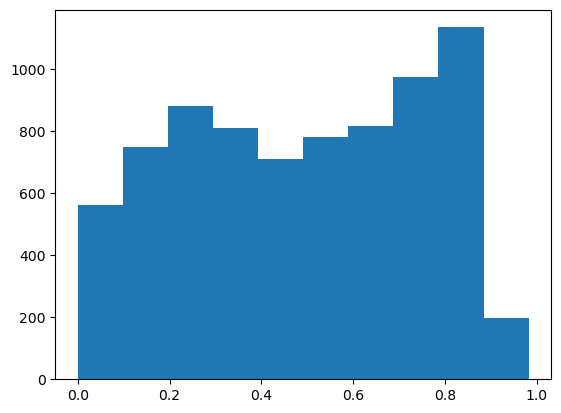

In [56]:
import matplotlib.pyplot as plt 
plt.hist(df_fold1["predict"])

In [49]:
df_fold1.to_csv("/home/feity/cryoem/temp/ribo_all_data_with_pred_gap1_fold2.csv", index=False)


In [50]:
torch.save(model.state_dict(), "/home/feity/cryoem/temp/particleid3d_ribo_gap1_fold1_train.pth")

In [36]:
roc_auc_score(df_fold1["label"], df_fold1["predict"])

0.7465766100213302